In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

c:\Users\DELL\Documents\advanced-phishing-website-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,URL,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,NoOfSubDomain,HasObfuscation,...,NoOfCSS,NoOfJS,NoOfExternalRef,label,URL_Length,Dot_Count,Slash_Count,Hyphen_Count,Digit_Count,HasHTTPS
0,https://www.southbankmosaics.com,31,24,0,100.0,1.000000,0.522907,0.061933,1,0,...,20,28,124,1,32,2,2,0,0,1
1,https://www.uni-mainz.de,23,16,0,100.0,0.666667,0.032650,0.050207,1,0,...,9,8,217,1,24,2,2,1,0,1
2,https://www.voicefmradio.co.uk,29,22,0,100.0,0.866667,0.028555,0.064129,2,0,...,2,7,5,1,30,3,2,0,0,1
3,https://www.sfnmjournal.com,26,19,0,100.0,1.000000,0.522907,0.057606,1,0,...,27,15,31,1,27,2,2,0,0,1
4,https://www.rewildingargentina.org,33,26,0,100.0,1.000000,0.079963,0.059441,1,0,...,15,34,85,1,34,2,2,0,0,1


In [3]:
X = df.drop(columns=["URL", "label"])

y = df["label"]

print(X.shape)
print(y.shape)

(235795, 40)
(235795,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [6]:
explainer = shap.TreeExplainer(rf_model)

In [7]:
sample = X_test.iloc[:100]

shap_values = explainer.shap_values(sample)

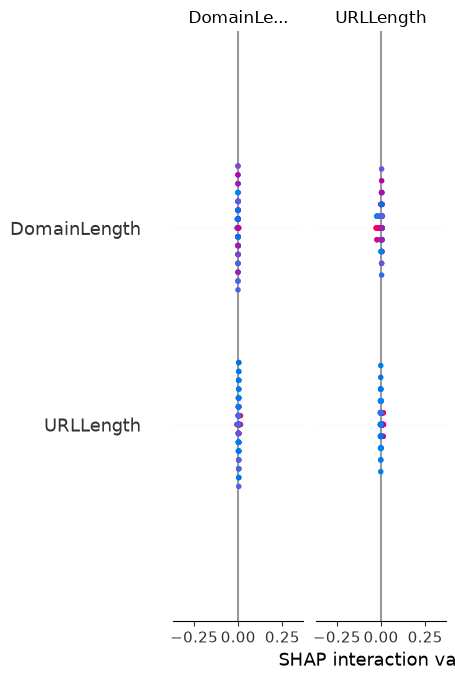

In [8]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

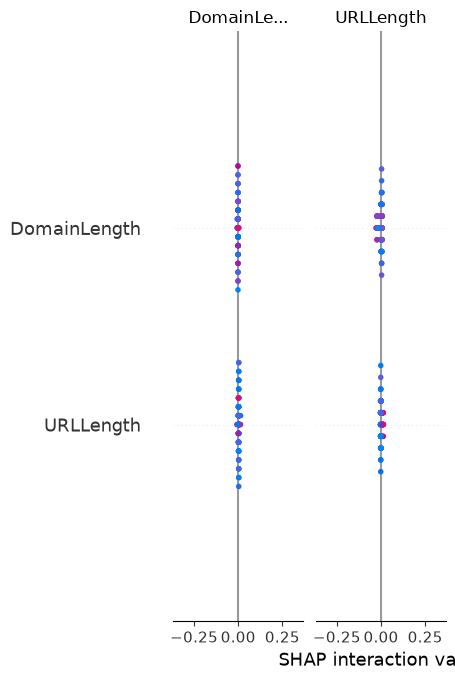

In [9]:
shap.summary_plot(
    shap_values,
    sample
)

In [10]:
sample = X_test.sample(200, random_state=42)

In [11]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(sample)

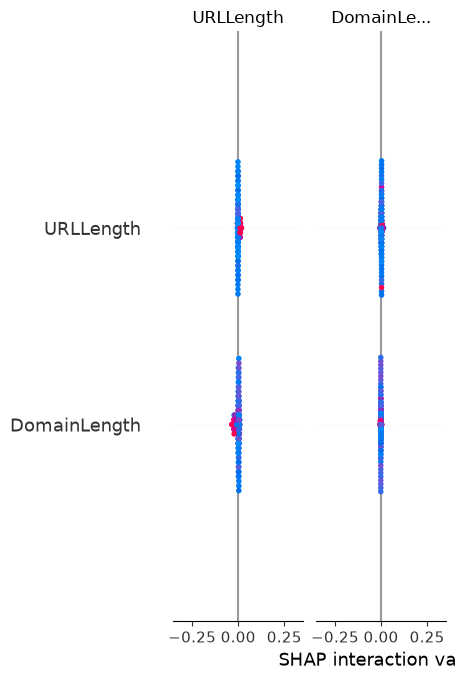

In [12]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

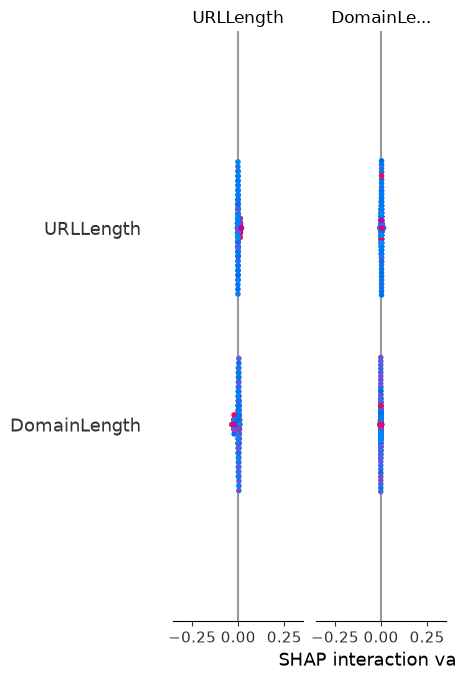

In [13]:
shap.summary_plot(
    shap_values,
    sample
)

In [14]:
type(shap_values)

numpy.ndarray

In [15]:
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else shap_values.shape)

<class 'numpy.ndarray'>
(200, 40, 2)


In [16]:
import shap
print(shap.__version__)

0.51.0


In [17]:
print(shap_values.shape)

(200, 40, 2)


In [18]:
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(200, 40)


In [24]:
X_test_sample = X_test.iloc[:200]

print(type(X_test_sample))
print(X_test_sample.shape)

<class 'pandas.DataFrame'>
(200, 40)


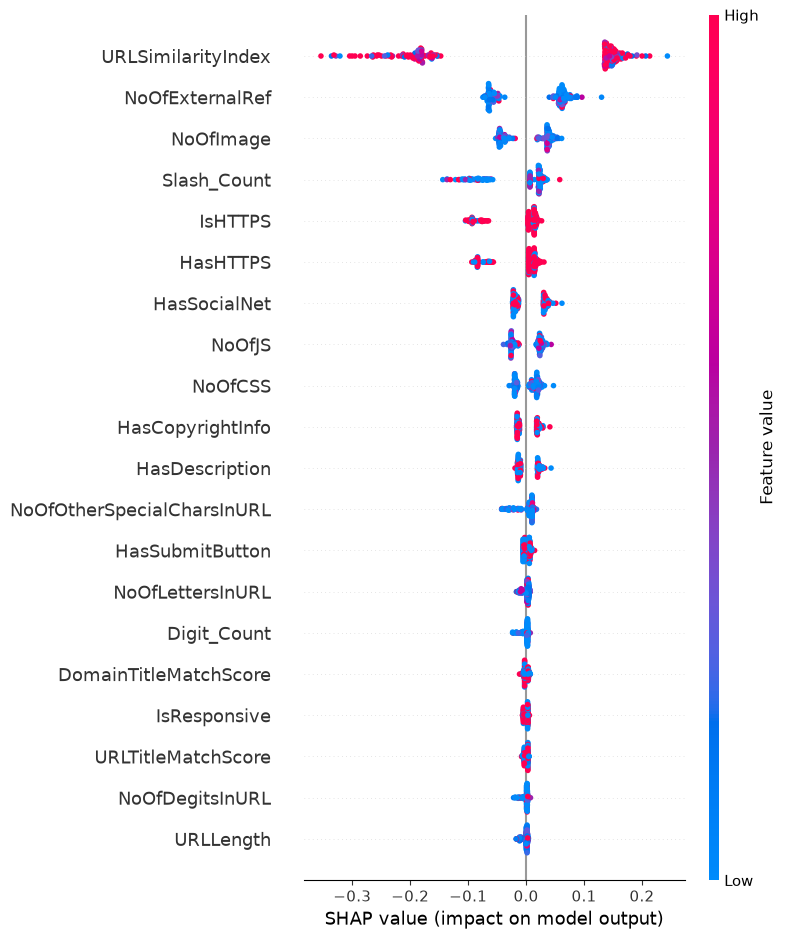

In [25]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    plot_type="dot"
)

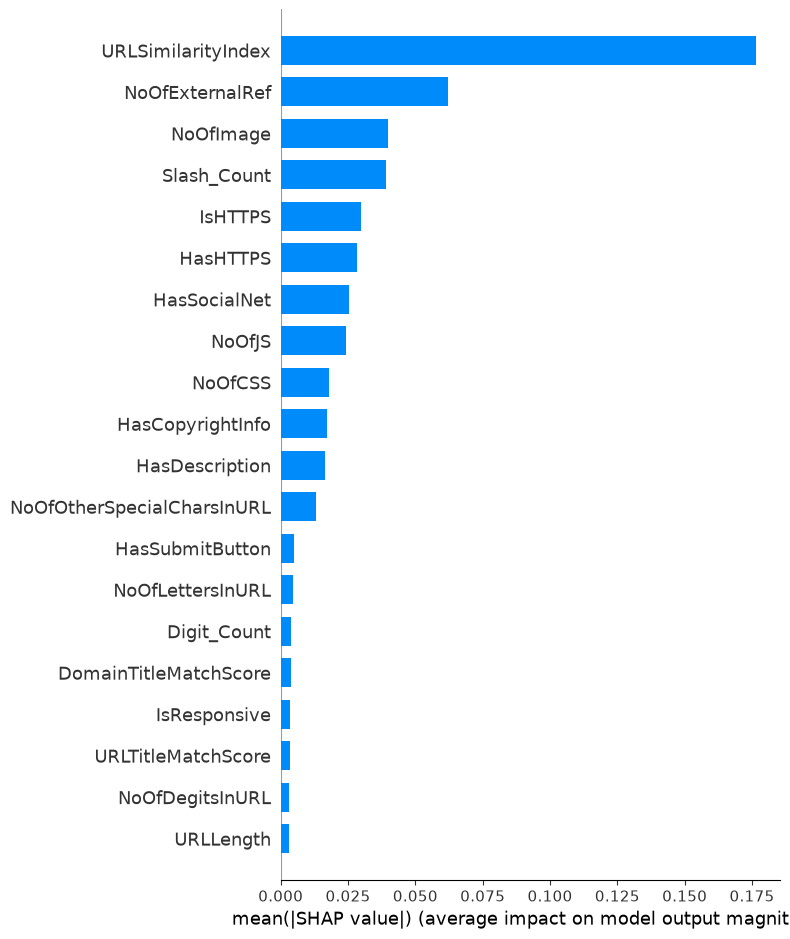

In [27]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    plot_type="bar"
)

In [23]:
print(type(shap_values_class1))
print(shap_values_class1.shape)

<class 'numpy.ndarray'>
(200, 40)


In [28]:
import joblib

In [29]:
joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

print("Model Saved Successfully.")

Model Saved Successfully.


In [30]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [31]:
loaded_model.predict(X_test.iloc[:5])

array([1, 1, 1, 1, 1])

In [32]:
print("Predictions:")

print(loaded_model.predict(X_test.iloc[:5]))

print()

print("Actual:")

print(y_test.iloc[:5].values)

Predictions:
[1 1 1 1 1]

Actual:
[1 1 1 1 1]
